<ipython-input-5-47de624b7f7e>:22: RuntimeWarning: invalid value encountered in divide
  z = y / np.sqrt(x * (1 - x))


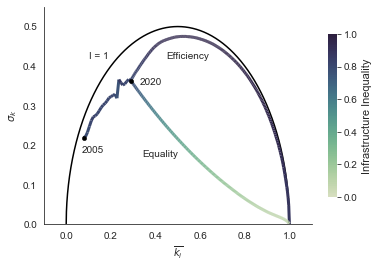

In [5]:
from helper import *

# Constants
data_path = "../data/pickle/brazil_growth_data"
PURPLE = (0.6953125, 0.66796875, 0.8203125)
ORANGE = (0.98828125, 0.71875, 0.38671875)
LAST_YEAR = 2020

# Styling
sns.set_style('white')

# Determine the max inequality as the square root of the binomial distribution
x_range = np.linspace(0, 1, 1000)
max_inequality = np.sqrt(x_range * (1 - x_range))

purple_palette = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)

def plot_colored_lines_with_interpolation(x, y, figure_ax, num_interp_points=250, colorbar=False):
    f = interp1d(x, y, kind='cubic')
    x = np.linspace(np.min(x), np.max(x), num_interp_points)
    y = f(x)
    z = y / np.sqrt(x * (1 - x))
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=purple_palette, norm=Normalize(vmin=0, vmax=1))
    lc.set_array(z)
    lc.set_linewidth(3)
    figure_ax.add_collection(lc)
    figure_ax.autoscale()
    figure_ax.margins(0.1)

    # Add a colorbar for the new plot
    if colorbar:
        cb = plt.colorbar(lc, ax=ax, shrink=0.75)
        cb.outline.set_visible(False)
        cb.set_label('Infrastructure Inequality', fontsize=11)

# Load the full dataset that contains all the cities and populations, create new columns
full_dataset = pd.read_csv("../data/raw/SNIS_2020_raw.csv")
full_dataset['Attended Population'] = full_dataset['Attended Population (sewer)']
full_dataset['Served Population'] = full_dataset['Attended Population (sewer)']
full_dataset = full_dataset.fillna(0)

# get historical data
historical_mu, historical_std = [], []
for year in range(2005, LAST_YEAR + 1):
    historical_population = full_dataset[full_dataset['Year'] == year]
    historical_mu.append(np.mean(historical_population['Attended Population'] / historical_population['Total Population']))
    historical_std.append(np.std(historical_population['Attended Population'] / historical_population['Total Population']))

with open(data_path, "rb") as fp:

    fig, ax = plt.subplots()
    efficiency_path, equality_path, efficiency_gini, equality_gini, efficiency_mean, equality_mean, efficiency_std, equality_std = pickle.load(fp)
    plt.plot(x_range, max_inequality, c='k', ls='-', zorder=1)
    plt.xlabel(r'$\overline{k_i}$')
    plt.ylabel(r'$\sigma_k$')
    sns.despine()
    plot_colored_lines_with_interpolation(efficiency_mean, efficiency_std, ax)
    plot_colored_lines_with_interpolation(equality_mean, equality_std, ax, colorbar=True)
    plot_colored_lines_with_interpolation(historical_mu, historical_std, ax, num_interp_points=25)
    sns.scatterplot(x=[historical_mu[0], efficiency_mean[0]], y=[historical_std[0], efficiency_std[0]],
                    color='k', alpha=1, zorder=100, edgecolor=None, s=20, ax=ax)
    plt.ylim(0, 0.55)
    plt.text(0.33, 0.353, '2020')
    plt.text(0.07, 0.18, '2005')
    plt.text(0.10, 0.42, 'I = 1')
    plt.text(0.45, 0.42, 'Efficiency')
    plt.text(0.34, 0.17, 'Equality')
    plt.show()